### Merged Video Game Metadata Dataset Exploration

In [1]:
import seaborn as sns
import pickle

cleaned_location = 'output/cleaned_df.pkl'

In [2]:
with open(cleaned_location, 'rb') as f:
    game_df = pickle.load(f)


In [3]:
print("Total entries:", len(game_df))
game_df.info()

Total entries: 447295
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 447295 entries, 0 to 447294
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   platform      447295 non-null  object        
 1   name          447295 non-null  object        
 2   filename      22895 non-null   object        
 3   summary       422870 non-null  object        
 4   release_date  345663 non-null  datetime64[ns]
 5   release_year  388697 non-null  Int64         
 6   genres        408315 non-null  object        
 7   developer     318171 non-null  object        
 8   publisher     313237 non-null  object        
 9   players       145982 non-null  Int64         
 10  cooperative   178750 non-null  boolean       
 11  rating        83407 non-null   Int64         
 12  user_rating   142483 non-null  float64       
dtypes: Int64(3), boolean(1), datetime64[ns](1), float64(1), object(7)
memory usage: 43.1+ MB


In [4]:
game_df.head()

,platform,name,filename,summary,release_date,release_year,genres,developer,publisher,players,cooperative,rating,user_rating
0,Android,&0,NaN,Detective otome game.,2022-05-30,2022,"Simulator, Visual Novel",Coly,Coly,<NA>,<NA>,<NA>,NaN
1,iOS,&0,NaN,Detective otome game.,2022-05-30,2022,"Simulator, Visual Novel",Coly,Coly,<NA>,<NA>,<NA>,NaN
2,Mac,0 = 0 = 0,NaN,Connect numbers together while diving deeper a...,2020-05-15,2020,Puzzle,kultisti,NaN,<NA>,<NA>,<NA>,NaN
3,Web Browser,0 = 0 = 0,NaN,Connect numbers together while diving deeper a...,2020-05-15,2020,Puzzle,kultisti,NaN,<NA>,<NA>,<NA>,NaN
4,Windows,0 = 0 = 0,NaN,Connect numbers together while diving deeper a...,2020-05-15,2020,Puzzle,kultisti,NaN,<NA>,<NA>,<NA>,NaN


In [5]:
# distinct platforms
print("Unique platform count:", game_df['platform'].nunique())
sorted(game_df['platform'].unique())

Unique platform count: 327


['1292 Advanced Programmable Video System',
 '3DO Interactive Multiplayer',
 'APF Imagination Machine',
 'AY-3-8500',
 'AY-3-8603',
 'AY-3-8605',
 'AY-3-8606',
 'AY-3-8607',
 'AY-3-8610',
 'AY-3-8760',
 'Aamber Pegasus',
 'Acorn Archimedes',
 'Acorn Atom',
 'Acorn Electron',
 'Advanced Pico Beena',
 'AirConsole',
 'Amazon Fire TV',
 'Amiga CD32',
 'Amstrad CPC',
 'Amstrad GX4000',
 'Amstrad PCW',
 'Analogue electronics',
 'Android',
 'Apogee BK-01',
 'Apple II',
 'Apple IIGS',
 'Apple Mac OS',
 'Apple Pippin',
 'Apple iOS',
 'Arcade',
 'Arcadia 2001',
 'Arduboy',
 'Atari 2600',
 'Atari 5200',
 'Atari 7800',
 'Atari 8-bit',
 'Atari 800',
 'Atari Jaguar',
 'Atari Jaguar CD',
 'Atari Lynx',
 'Atari ST',
 'Atari XEGS',
 'BBC Microcomputer System',
 'Bally Astrocade',
 'Bandai Super Vision 8000',
 'Bandai WonderSwan',
 'Bandai WonderSwan Color',
 'BlackBerry OS',
 'Blu-ray Player',
 'CDC Cyber 70',
 'Call-A-Computer time-shared mainframe computer system',
 'Camputers Lynx',
 'Card-e Reader'

In [6]:
# platform counts
platform_counts = game_df['platform'].value_counts()
print("Platform counts:")
print(platform_counts)

Platform counts:
platform
Windows            134664
Mac                 25141
Nintendo Switch     19239
Linux               16518
iOS                 15682
                    ...  
PDP-1                   1
Sol-20                  1
AY-3-8605               1
Donner Model 30         1
Virtual Console         1
Name: count, Length: 327, dtype: int64


In [7]:
distinct_name_count = game_df['name'].nunique()
print("Unique game name count:", distinct_name_count)

Unique game name count: 270112


<Axes: xlabel='summary_word_count', ylabel='Count'>

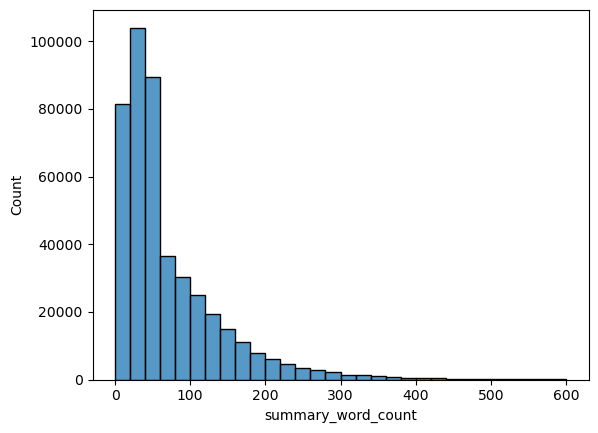

In [8]:
# count summary words
summary_limit = 600
game_df['summary_word_count'] = game_df['summary'].apply(lambda x: len(x.split()) if isinstance(x, str) else 0)
sns.histplot(game_df[game_df['summary_word_count'] <= summary_limit]['summary_word_count'], bins=30)

<Axes: xlabel='summary_length', ylabel='Count'>

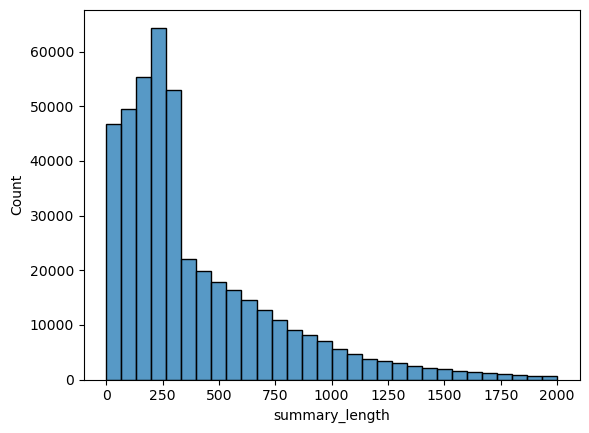

In [9]:
# summary length distribution for non missing, limit to x characters for better visualization

summary_limit = 2000
game_df['summary_length'] = game_df['summary'].apply(lambda x: len(x) if isinstance(x, str) else 0)
sns.histplot(game_df[game_df['summary_length'] <= summary_limit]['summary_length'], bins=30)


In [16]:
# sample of shortest descriptions and longest descriptions
shortest_summaries = game_df[game_df['summary_length'] > 0].nsmallest(10, 'summary_length')[['name', 'summary_length', 'summary']]
longest_summaries = game_df.nlargest(10, 'summary_length')[['name', 'summary_length', 'summary']]

print("Shortest Summaries:")
print(shortest_summaries.to_string(index=False))
print("\nLongest Summaries:")
print(longest_summaries.to_string(index=False))

Shortest Summaries:
                                                                     name  summary_length summary
                        Grand Theft Auto III: 10 Year Anniversary Edition               1       I
                                                                      His               1       -
                                                              Space Force               1       .
King of Fighters R-1: Pocket Kakutou Series & Melon-chan no Seichou Nikki               4    Demo
                                                         Shaw's Nightmare               4    Null
                                                                   Snakes               4    Null
                                                              Vzlom Zhopy               4    GOTY
                                                               В Подъезде               4    Гыгы
                                                        Balance The Stick               5   stick


For ML mode

<Axes: xlabel='release_year', ylabel='Count'>

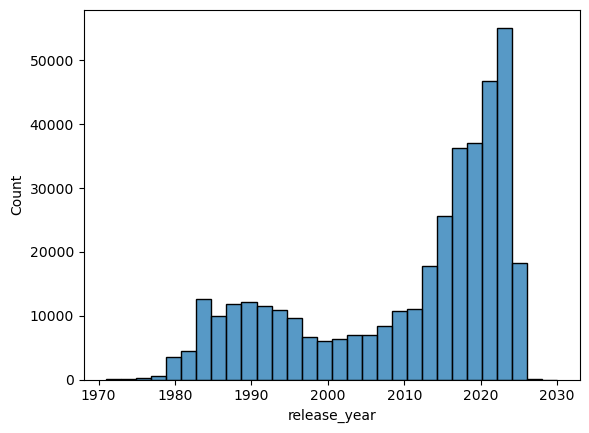

In [11]:
# release_year distribution for values over 1970
sns.histplot(game_df[game_df['release_year'] > 1970]['release_year'], bins=30)

In [12]:
# dev and publisher counts
print("Unique developer count:", game_df['developer'].nunique())
print("Unique publisher count:", game_df['publisher'].nunique())

Unique developer count: 89356
Unique publisher count: 69156


In [13]:
# most popular developer
top_developers = game_df['developer'].value_counts().head(10)
print("Top 10 Developers:")
print(top_developers)

# top publisher
top_publishers = game_df['publisher'].value_counts().head(10)
print("\nTop 10 Publishers:")
print(top_publishers)

Top 10 Developers:
developer
Konami         2106
Capcom         1371
Namco           787
Taito           766
Koei            759
Sega            730
SNK             714
Hudson Soft     663
Nintendo        642
Infocom         523
Name: count, dtype: int64

Top 10 Publishers:
publisher
Nintendo                   3072
Freeware, Public Domain    3000
Konami                     2841
Electronic Arts            2479
Sega                       2202
Activision                 1721
Capcom                     1594
Square Enix                1177
Freeware                   1169
THQ                         975
Name: count, dtype: int64


In [14]:
# duplicate rates, not including platforms
duplicate_names = game_df['name'].duplicated().sum()
total_entries = len(game_df)
duplicate_rate = duplicate_names / total_entries * 100
print(f"\nDuplicate game names: {duplicate_names} ({duplicate_rate:.2f}%)")


Duplicate game names: 177183 (39.61%)


In [15]:
# metadata completeness by row

metadata_fields = ['summary', 'genres', 'release_year']

cumulative_non_missing = []

for i in range(len(metadata_fields)):
    cols = metadata_fields[: i + 1]
    row_count = game_df[cols].notna().all(axis=1).sum()
    row_pct = (row_count / len(game_df)) * 100

    cumulative_non_missing.append({
        "field_set": tuple(cols),
        "row_count": int(row_count),
        "row_pct": row_pct
    })

    print(
        f"{i+1:2d}. {tuple(cols)} -> {row_pct:.2f}% "
        f"({row_count:,}/{len(game_df):,})"
    )



 1. ('summary',) -> 94.54% (422,870/447,295)
 2. ('summary', 'genres') -> 89.11% (398,593/447,295)
 3. ('summary', 'genres', 'release_year') -> 79.21% (354,301/447,295)
